In [1]:
import os
from PIL import Image
import imagehash
from collections import defaultdict 

In [2]:
train_dir = "../dataset/raw/Training"
test_dir = "../dataset/raw/Testing"

Detect Corrupted Images

In [3]:
def find_corrupted_images(dataset_path):

    corrupted = []

    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            path = os.path.join(root, file)
            try:
                img = Image.open(path)
                img.verify()

            except Exception:
                corrupted.append(path)

    return corrupted

train_corrupted = find_corrupted_images(train_dir)
test_corrupted = find_corrupted_images(test_dir)

print("Train Corrupted Images:", len(train_corrupted))
print("Test Corrupted Images:", len(test_corrupted))

Train Corrupted Images: 0
Test Corrupted Images: 0


Display Corrupted Files

In [4]:
for img in train_corrupted:
    print(img)

for img in test_corrupted:
    print(img)

Detect Duplicate Images

In [5]:
def find_duplicates(dataset_path):

    hashes = defaultdict(list)

    for root, dirs, files in os.walk(dataset_path):

        for file in files:

            path = os.path.join(root, file)

            try:
                img = Image.open(path)

                hash_value = str(imagehash.average_hash(img))

                hashes[hash_value].append(path)

            except:
                pass

    duplicates = []

    for hash_value, paths in hashes.items():

        if len(paths) > 1:
            duplicates.append(paths)

    return duplicates

duplicates = find_duplicates(train_dir)

print("Duplicate Groups Found:", len(duplicates))


Duplicate Groups Found: 726


Inspect Duplicate Images

In [6]:
for i, group in enumerate(duplicates[:10]):
    print(f"\nDuplicate Group {i+1}")

    for path in group:
        print(path)


Duplicate Group 1
../dataset/raw/Training\glioma\Tr-glTr_0001.jpg
../dataset/raw/Training\glioma\Tr-gl_0704.jpg
../dataset/raw/Training\glioma\Tr-gl_0705.jpg
../dataset/raw/Training\glioma\Tr-gl_1159.jpg
../dataset/raw/Training\glioma\Tr-gl_1184.jpg
../dataset/raw/Training\glioma\Tr-gl_1185.jpg
../dataset/raw/Training\meningioma\Tr-me_0100.jpg
../dataset/raw/Training\meningioma\Tr-me_0150.jpg
../dataset/raw/Training\meningioma\Tr-me_0160.jpg
../dataset/raw/Training\meningioma\Tr-me_0388.jpg
../dataset/raw/Training\meningioma\Tr-me_0433.jpg
../dataset/raw/Training\meningioma\Tr-me_0436.jpg
../dataset/raw/Training\meningioma\Tr-me_0881.jpg
../dataset/raw/Training\meningioma\Tr-me_0888.jpg
../dataset/raw/Training\meningioma\Tr-me_0928.jpg
../dataset/raw/Training\meningioma\Tr-me_0963.jpg
../dataset/raw/Training\meningioma\Tr-me_0964.jpg
../dataset/raw/Training\notumor\Tr-no_0247.jpg
../dataset/raw/Training\notumor\Tr-no_1142.jpg

Duplicate Group 2
../dataset/raw/Training\glioma\Tr-glTr_0

Check Image Format

In [7]:
formats = {}

for root, dirs, files in os.walk(train_dir):

    for file in files:

        ext = os.path.splitext(file)[1].lower()

        formats[ext] = formats.get(ext, 0) + 1

formats

{'.jpg': 5712}

Checking RGB / GrayScale Distribution

In [8]:
rgb_count = 0
gray_count = 0

for root, dirs, files in os.walk(train_dir):

    for file in files[:100]:

        path = os.path.join(root, file)

        try:
            img = Image.open(path)

            if img.mode == "RGB":
                rgb_count += 1
            else:
                gray_count += 1

        except:
            pass

print("RGB Images:", rgb_count)
print("Non-RGB Images:", gray_count)

RGB Images: 400
Non-RGB Images: 0


Dataset Health Report

In [9]:
health_report = {
    "Corrupted Images": len(train_corrupted) + len(test_corrupted),
    "Duplicate Groups": len(duplicates),
    "Formats Found":formats
}

health_report

{'Corrupted Images': 0,
 'Duplicate Groups': 726,
 'Formats Found': {'.jpg': 5712}}

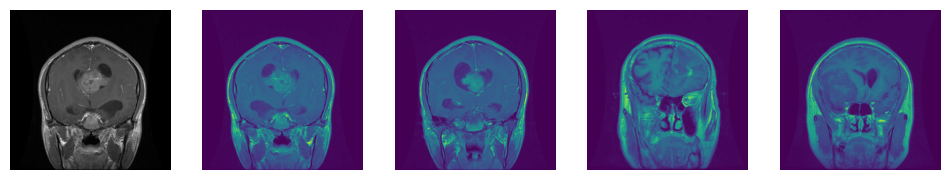

In [10]:
import matplotlib.pyplot as plt
from PIL import Image

group = duplicates[0]

plt.figure(figsize=(12,4))

for i, path in enumerate(group[:5]):

    img = Image.open(path)

    plt.subplot(1, len(group[:5]), i+1)
    plt.imshow(img)
    plt.axis("off")

plt.show()